# Pandas — Data Cleaning

> **Repo:** Python_Libraries | **Library:** Pandas  
> **Notebook:** 04_Data_Cleaning  

---

**Data Cleaning with Pandas**

Data cleaning is the process of identifying and fixing errors, inconsistencies, and missing information in a dataset before analysis.

Real-world data is almost never clean.

This notebook walks through the most important data cleaning techniques in Pandas using the **Titanic dataset** as our working example.

**What we'll cover:**
1. Introduction to Dirty Data
2. Handling Missing Values
3. Fixing Data Types
4. Renaming & Reindexing
5. Removing Duplicates
6. String Cleaning
7. Outlier Detection (IQR + Z-score)
8. A Mini Cleaning Pipeline

## Section 1: Importing Libraries and Loading Dataset

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Titanic dataset directly from seaborn
df_raw = sns.load_dataset('titanic')

# Keeping a clean copy — so as not to mutate the original one
df = df_raw.copy()

df.sample(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
517,0,3,male,NaN,0,0,24.1500,Q,Third,man,True,NaN,Queenstown,no,True
775,0,3,male,18.0,0,0,7.7500,S,Third,man,True,NaN,Southampton,no,True
306,1,1,female,NaN,0,0,110.8833,C,First,woman,False,NaN,Cherbourg,yes,True


## Section 2: First Look at the Dirty Data

Before cleaning anything, we diagnose the dataset.

**Key questions:**
- What are the columns and their data types?
- Which columns have missing values, and how many?
- Are there any obvious structural issues?

In [22]:
df.shape

(891, 15)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [24]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})

missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


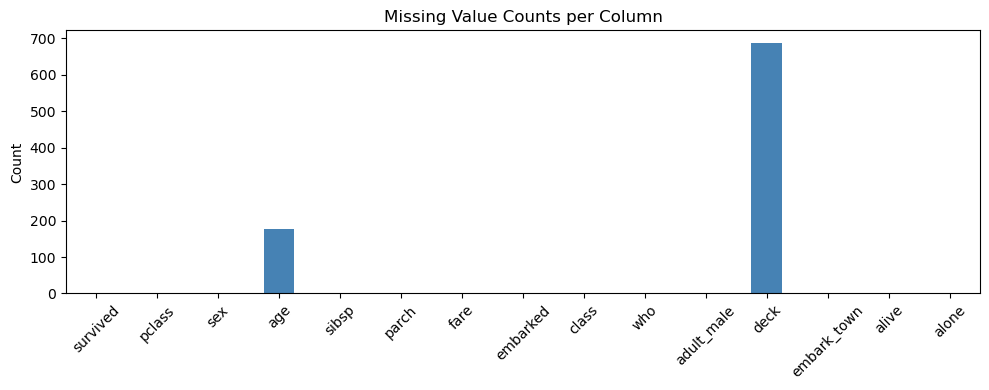

In [26]:
plt.figure(figsize=(10, 4))
df.isnull().sum().plot(kind='bar', color='steelblue')
plt.title('Missing Value Counts per Column')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Section 3 — Handling Missing Values

Strategy depends on how much data is missing and how important the column is:
- **Drop the column** → if missing > ~60% or column is redundant
- **Fill with median** → for numeric columns (robust to outliers)
- **Fill with mode** → for categorical columns
- **Drop the row** → if very few rows are affected

In [30]:
# Dropping for two distinct reasons:
# - 'deck' : 77% missing values — not recoverable
# - others : redundant columns (duplicates of survived(alive), pclass(class), embarked(embark_town), sex+age(who & adult_male))
cols_to_drop = ['deck', 'alive', 'class', 'embark_town', 'who', 'adult_male']
df.drop(columns=cols_to_drop, inplace=True)

print("Remaining columns:", df.columns.tolist())

Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


In [36]:
median_age = df['age'].median()
df.fillna({'age':median_age}, inplace=True)

print(f"Age filled with median: {median_age}")
print("Missing in age:", df['age'].isnull().sum())

Age filled with median: 28.0
Missing in age: 0


In [38]:
mode_embarked = df['embarked'].mode()[0]
df.fillna({'embarked': mode_embarked}, inplace=True)

print(f"Embarked filled with mode: '{mode_embarked}'")
print("Missing in embarked:", df['embarked'].isnull().sum())

Embarked filled with mode: 'S'
Missing in embarked: 0


In [40]:
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64

## Section 4 — Fixing Data Types

Columns can be stored in the wrong type, which affects:
- Memory usage
- How operations behave (e.g. mean of a category makes no sense)
- Correctness of ML models downstream

Common fixes:
- `astype()` → general type conversion
- `pd.to_numeric()` → safely parse numbers, coerce errors to NaN
- `pd.to_datetime()` → parse date strings

In [43]:
df.dtypes

survived      int64
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
alone          bool
dtype: object

In [45]:
df['survived'] = df['survived'].astype('category')
df['pclass'] = df['pclass'].astype('category')

df[['survived', 'pclass']].dtypes

survived    category
pclass      category
dtype: object

In [47]:
# Simulate a dirty numeric column with a bad entry
test_series = pd.Series(['23', '45', 'unknown', '31', None])

# errors='coerce' turns unparseable values into NaN instead of crashing
pd.to_numeric(test_series, errors='coerce')

0    23.0
1    45.0
2     NaN
3    31.0
4     NaN
dtype: float64

## Section 5 — Renaming & Reindexing

Clean column names make code readable and prevent bugs.

Key tools:
- `rename()` → rename specific columns
- `reset_index()` → restore default 0-based index after filtering
- `set_index()` → promote a column to the index

In [50]:
df.rename(columns={
    'sibsp': 'siblings_spouses',
    'parch': 'parents_children',
    'pclass': 'passenger_class',
}, inplace=True)

df.columns.tolist()

['survived',
 'passenger_class',
 'sex',
 'age',
 'siblings_spouses',
 'parents_children',
 'fare',
 'embarked',
 'alone']

In [58]:
# Simulate filtering — index becomes non-contiguous
df_filtered = df[df['survived'] == 1]

print("Index before reset:", df_filtered.index.tolist()[:10])

df_filtered = df_filtered.reset_index(drop=True)
print("Index after reset: ", df_filtered.index.tolist()[:10])

# Note: when a column is category dtype, comparisons must match
# the original value type — use 1 (int), not '1' (str)

Index before reset: [1, 2, 3, 8, 9, 10, 11, 15, 17, 19]
Index after reset:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [54]:
# Temporarily set 'survived' as the index — just for illustration
df_indexed = df.set_index('survived')
df_indexed.head(3)

,passenger_class,sex,age,siblings_spouses,parents_children,fare,embarked,alone
survived,,,,,,,,
0,3,male,22.0,1,0,7.2500,S,False
1,1,female,38.0,1,0,71.2833,C,False
1,3,female,26.0,0,0,7.9250,S,True


## Section 6 — Removing Duplicates

Duplicate rows silently skew every metric — counts, means, model trainin
g.
Key tools:
- `duplicated()` → flags duplicate rows as True/False
- `drop_duplicates()` → removes them

In [61]:
print("Duplicate rows found:", df.duplicated().sum())
df[df.duplicated(keep=False)]   # show all copies, not just the second occurrence

Duplicate rows found: 116


,survived,passenger_class,sex,age,siblings_spouses,parents_children,fare,embarked,alone
4,0,3,male,35.0,0,0,8.0500,S,True
23,1,1,male,28.0,0,0,35.5000,S,True
26,0,3,male,28.0,0,0,7.2250,C,True
28,1,3,female,28.0,0,0,7.8792,Q,True
29,0,3,male,28.0,0,0,7.8958,S,True
...,...,...,...,...,...,...,...,...,...
870,0,3,male,26.0,0,0,7.8958,S,True
877,0,3,male,19.0,0,0,7.8958,S,True
878,0,3,male,28.0,0,0,7.8958,S,True
884,0,3,male,25.0,0,0,7.0500,S,True


In [63]:
# Artificially inject duplicates to demonstrate the technique
df_duped = pd.concat([df, df.iloc[:5]], ignore_index=True)

print("Shape with duplicates:", df_duped.shape)
print("Duplicate count:", df_duped.duplicated().sum())

# Remove duplicates
df_duped = df_duped.drop_duplicates(ignore_index=True)

print("Shape after dropping:", df_duped.shape)
print("Duplicate count after:", df_duped.duplicated().sum())

Shape with duplicates: (896, 9)
Duplicate count: 121
Shape after dropping: (775, 9)
Duplicate count after: 0


In [65]:
# Sometimes you only care about duplicates in specific columns
# e.g. same passenger_class + fare + age is suspicious
df.duplicated(subset=['passenger_class', 'fare', 'age']).sum()

187

> Note:

- 116 duplicates detected, but most are imputation artifacts —
-  rows where missing age was filled with the same median (28.0)
- Therefore, we should w Always investigate WHY duplicates exist before dropping them.

## Section 7 — String Cleaning

String columns often carry hidden noise — extra spaces, inconsistent casin ,
or stray characters — that break grouping, merging, and analysis.

Key tools (all under `.str` accessor):
- `.str.strip()` → remove leading/trailing whitespace
- `.str.lower()` / `.str.upper()` → normalize casing
- `.str.replace()` → substitute characters or patterns
- `.str.contains()` → filter rows by pattern

In [69]:
# Simulate a dirty 'sex' column
dirty = pd.Series(['  male', 'Female ', ' MALE', 'female', '  Female  '])

cleaned = dirty.str.strip().str.lower()
print(cleaned.value_counts())

female    3
male      2
Name: count, dtype: int64


In [71]:
print("Before cleaning:")
print(df['sex'].unique())
print(df['embarked'].unique())

# Clean both columns defensively (good habit even if already clean)
df['sex'] = df['sex'].str.strip().str.lower()
df['embarked'] = df['embarked'].str.strip().str.lower()

print("\nAfter cleaning:")
print(df['sex'].unique())
print(df['embarked'].unique())

Before cleaning:
['male' 'female']
['S' 'C' 'Q']

After cleaning:
['male' 'female']
['s' 'c' 'q']


In [73]:
# str.replace — e.g. normalize an embarked column to full words
embarked_map = df['embarked'].str.replace('s', 'Southampton', regex=False)
embarked_map = embarked_map.str.replace('c', 'Cherbourg', regex=False)
embarked_map = embarked_map.str.replace('q', 'Queenstown', regex=False)
print(embarked_map.value_counts())

# str.contains — filter rows where embarked is Southampton
df[df['embarked'].str.contains('s', na=False)].shape

embarked
Southampton    646
Cherbourg      168
Queenstown      77
Name: count, dtype: int64


(646, 9)

## Section 8 — Outlier Detection

Outliers are data points that lie far from the rest of the distribution.
They can distort means, skew models, and mislead analysis.

Two standard detection methods:
- **IQR method** → based on spread of the middle 50% of data (robust)
- **Z-score method** → based on standard deviations from the mean (assumes normal distribution)

We'll inspect the `age` and `fare` columns.

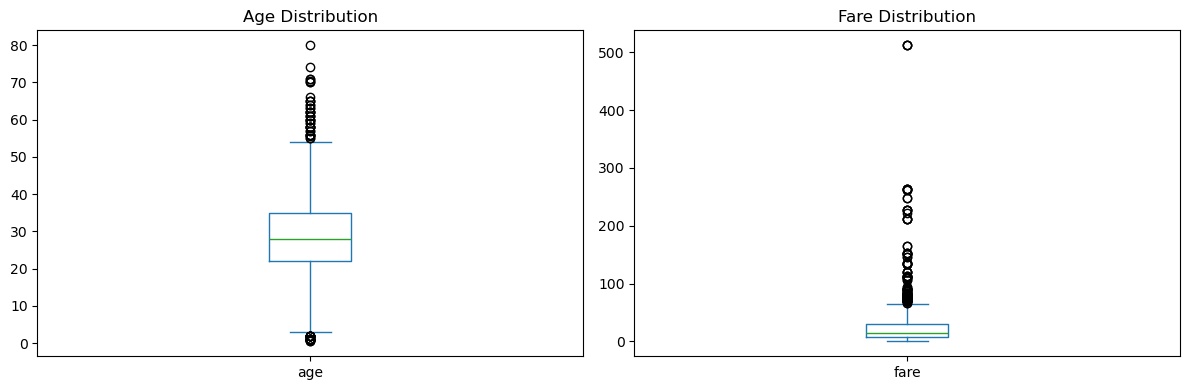

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['age'].plot(kind='box', ax=axes[0], title='Age Distribution')
df['fare'].plot(kind='box', ax=axes[1], title='Fare Distribution')

plt.tight_layout()
plt.show()

In [78]:
# IQR Method
def flag_outliers_iqr(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (col < lower) | (col > upper)

age_outliers_iqr  = flag_outliers_iqr(df['age'])
fare_outliers_iqr = flag_outliers_iqr(df['fare'])

print(f"Age  outliers (IQR): {age_outliers_iqr.sum()}")
print(f"Fare outliers (IQR): {fare_outliers_iqr.sum()}")

Age  outliers (IQR): 66
Fare outliers (IQR): 116


In [80]:
# Z Score Method
def flag_outliers_zscore(col, threshold=3):
    z_scores = (col - col.mean()) / col.std()
    return z_scores.abs() > threshold

age_outliers_z  = flag_outliers_zscore(df['age'])
fare_outliers_z = flag_outliers_zscore(df['fare'])

print(f"Age  outliers (Z-score): {age_outliers_z.sum()}")
print(f"Fare outliers (Z-score): {fare_outliers_z.sum()}")

Age  outliers (Z-score): 7
Fare outliers (Z-score): 20


In [82]:
# Comparing both the Methods
comparison = pd.DataFrame({
    'age_iqr':    age_outliers_iqr,
    'age_zscore': age_outliers_z,
    'fare_iqr':   fare_outliers_iqr,
    'fare_zscore': fare_outliers_z
})

comparison.sum().to_frame(name='outlier_count')

,outlier_count
age_iqr,66
age_zscore,7
fare_iqr,116
fare_zscore,20


#### Key Insights:

- IQR is robust but sensitive on skewed distributions — flags more outliers.
- Z-score assumes normality — misses outliers when distribution is skewed.

#### Rule of Thumb:

- Skewed data (like fare) → prefer IQR
- Roughly normal data (like age) → either works, Z-score is more conservative.

##  Section 9 — Mini Cleaning Pipeline

A real cleaning pipeline applies all steps systematically on raw data.

This section consolidates everything from Sections 2–8 into one reusable function.

In [90]:
def clean_titanic(raw_df):
    df = raw_df.copy()

    # 1. Drop redundant and high-missing columns
    cols_to_drop = ['deck', 'alive', 'class', 'embark_town', 'who', 'adult_male']
    df.drop(columns=cols_to_drop, inplace=True)

    # 2. Fill missing values
    df.fillna({'age': df['age'].median()}, inplace=True)
    df.fillna({'embarked': df['embarked'].mode()[0]}, inplace=True)

    # 3. Fix data types
    df['survived'] = df['survived'].astype('category')
    df['pclass'] = df['pclass'].astype('category')

    # 4. Rename columns
    df.rename(columns={
        'sibsp': 'siblings_spouses',
        'parch': 'parents_children',
        'pclass': 'passenger_class'
    }, inplace=True)

    # 5. Clean strings
    df['sex'] = df['sex'].str.strip().str.lower()
    df['embarked'] = df['embarked'].str.strip().str.lower()

    # 6. Flag outliers (without dropping — let analyst decide)
    def iqr_outlier_flag(col):
        Q1, Q3 = col.quantile(0.25), col.quantile(0.75)
        IQR = Q3 - Q1
        return (col < Q1 - 1.5 * IQR) | (col > Q3 + 1.5 * IQR)

    df['age_outlier']  = iqr_outlier_flag(df['age'])
    df['fare_outlier'] = iqr_outlier_flag(df['fare'])

    return df

df_clean = clean_titanic(df_raw)
df_clean.shape

(891, 11)

In [92]:
print("Missing values:\n", df_clean.isnull().sum())
print("\nDtypes:\n", df_clean.dtypes)
print("\nSample:")
df_clean.head(3)

Missing values:
 survived            0
passenger_class     0
sex                 0
age                 0
siblings_spouses    0
parents_children    0
fare                0
embarked            0
alone               0
age_outlier         0
fare_outlier        0
dtype: int64

Dtypes:
 survived            category
passenger_class     category
sex                   object
age                  float64
siblings_spouses       int64
parents_children       int64
fare                 float64
embarked              object
alone                   bool
age_outlier             bool
fare_outlier            bool
dtype: object

Sample:


,survived,passenger_class,sex,age,siblings_spouses,parents_children,fare,embarked,alone,age_outlier,fare_outlier
0,0,3,male,22.0,1,0,7.2500,s,False,False,False
1,1,1,female,38.0,1,0,71.2833,c,False,False,True
2,1,3,female,26.0,0,0,7.9250,s,True,False,False


## Summary

This notebook covered a complete data cleaning workflow using the Titanic dataset.

| Section | Technique | Key Tool |
|---|---|---|
| 2 | Diagnosing dirty data | `isnull()`, `info()` |
| 3 | Handling missing values | `fillna()`, median, mode |
| 4 | Fixing data types | `astype()`, `pd.to_numeric()` |
| 5 | Renaming & reindexing | `rename()`, `reset_index()` |
| 6 | Removing duplicates | `duplicated()`, `drop_duplicates()` |
| 7 | String cleaning | `.str.strip()`, `.str.lower()`, `.str.replace()` |
| 8 | Outlier detection | IQR method, Z-score method |
| 9 | Full pipeline | Reusable `clean_titanic()` function |

**Key takeaways:**
- Always keep a raw copy — never mutate the original DataFrame
- Investigate *why* duplicates exist before dropping them
- IQR suits skewed distributions; Z-score assumes normality
- Flag outliers rather than drop them — let the analyst decide